# OPRD-100 Dataset Analysis

This notebook provides comprehensive analysis of the OPRD-100 dataset, including:
- Reaction data locations and completeness of reactivity data
- Yield types and distributions  
- Stereochemistry analysis
- Solvent usage and environmental assessment
- Reaction conditions (temperature and time)
- Catalyst usage

The OPRD-100 dataset contains reactions extracted from 100 Organic Process Research & Development articles, capturing both structured reaction data from schemes/tables and contextual information from experimental sections.

In [1]:
# Import required libraries
import json
import os
import re
import math
import sys
import pandas as pd
import numpy as np
from collections import defaultdict

# Add the src directory to Python path for imports
sys.path.insert(0, os.path.abspath('../src'))

from PlottingFunctions import Plot
from ReaxysComparison import ReaxysDataExtractor
from Stereochemistry import CheckStereochemistry, ReactionParser

# Set default figure styling
figsize = (3, 2)
title_fontdict = {'fontsize': 14, 'fontweight': 'bold'}
label_fontdict = {'fontsize': 14}
tick_fontdict = {'fontsize': 14, 'fontweight': 'bold'}
legend_fontdict = {'size': 14}

# Set output filepath for figures
filepath = "../output/analysis_figures/"
# Define dataset paths
oprd_100_path = "../data/OPRD-100.json"

/home/ghodgin/miniconda3/envs/oprd100/lib/python3.12/site-packages/rxnmapper/batched_mapper.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Utility functions
def json_to_dict(file_path):
    """Reads a JSON file and converts it to a dictionary."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist.")
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def _has_value(v):
    """Checks if a value is None or a list of None values."""
    if v is None:
        return False
    if isinstance(v, str):
        if not v.strip():
            return False
        if v.lower() in {None, "null", "none", "nan"}:
            return False
    if isinstance(v, list):
        if not v:
            return False
        if all(item is None for item in v):
            return False
    return True

# Load OPRD-100 dataset
oprd_100_data = json_to_dict(oprd_100_path)
print(f"Loaded {len(oprd_100_data)} reactions from OPRD-100 dataset")

Loaded 3878 reactions from OPRD-100 dataset


## 1. Reaction Data Locations and Completeness

This section analyzes where reaction data is reported in scientific articles (e.g., schemes, tables, experimental sections) and assesses the completeness of reactivity data (yield, temperature, time, and solvent information).

In [3]:
class ReactionDataExtractor:
    """Extract and analyze reaction data from OPRD-100 dataset."""
    
    def __init__(self, json_file=None):
        if json_file is not None:
            with open(json_file, 'r') as f:
                self.data = json.load(f)
        self.total_count = 0

    def has_yield(self, reaction_data):
        """Check if the final step has a yield, excluding 'other'."""
        if 'Steps' in reaction_data and reaction_data['Steps']:
            final_step = reaction_data['Steps'][-1]
            yield_info = final_step.get('Yield', {})
            return any(key != 'other' and _has_value(value) for key, value in yield_info.items())
        return False
    
    def has_temperature(self, reaction_data):
        """Check if all steps have a recorded temperature."""
        if 'Steps' in reaction_data:
            return all(_has_value(step.get('Temperature')) for step in reaction_data['Steps'])
        return False
    
    def has_time(self, reaction_data):
        """Check if all steps have a recorded time."""
        if 'Steps' in reaction_data:
            return all(_has_value(step.get('Time')) for step in reaction_data['Steps'])
        return False
    
    def has_solvent(self, reaction_data):
        """Check if any step contains a solvent."""
        if 'Steps' in reaction_data:
            return any(_has_value(step.get('Solvents')) for step in reaction_data['Steps'])
        return False
    
    def extract_reactivity_data_by_location(self):
        """Extract yield, temperature, time, and solvent presence grouped by reaction location."""
        location_data = defaultdict(lambda: {
            'yield': 0, 'temperature': 0, 'time': 0, 'solvent': 0, 'count': 0, 'has all': 0
        })
        
        keywords = ["scheme", "figure", "table", "experimental", "text"]
        
        for reaction_data in self.data:
            self.total_count += 1
            if not reaction_data:
                continue
            
            raw_location = reaction_data.get('Location', {}).get('Type', '').lower()
            raw_location = re.sub(r'\b(results and discussion)\b', 'text', raw_location)
            
            found = set(re.findall(r'\b(?:' + '|'.join(keywords) + r')\b', raw_location))
            
            if not found:
                location = "Unknown"
            else:
                location = " & ".join(sorted(word.capitalize() for word in found))
            
            location_data[location]['count'] += 1
            location_data[location]['yield'] += self.has_yield(reaction_data)
            location_data[location]['temperature'] += self.has_temperature(reaction_data)
            location_data[location]['time'] += self.has_time(reaction_data)
            location_data[location]['solvent'] += self.has_solvent(reaction_data)
            location_data[location]['has all'] += all([
                self.has_yield(reaction_data),
                self.has_temperature(reaction_data),
                self.has_time(reaction_data),
                self.has_solvent(reaction_data)
            ])
        
        return location_data

# Extract OPRD-100 location data
rxn_extractor = ReactionDataExtractor(json_file='../data/OPRD-100.json')
oprd_loc_data = rxn_extractor.extract_reactivity_data_by_location()
oprd_loc_data = pd.DataFrame.from_dict(oprd_loc_data, orient='index')

print("\nOPRD-100 Reaction Data by Location:")
print(oprd_loc_data.sort_values('count', ascending=False))


OPRD-100 Reaction Data by Location:
                               yield  temperature  time  solvent  count  \
Table                           1528         1198  1329     1724   1724   
Scheme                           523          295   135      894    894   
Experimental                     554          429   471      590    590   
Scheme & Table                   189          183   190      250    250   
Figure                            41           85    75      104    104   
Experimental & Table              48           66    71       71     71   
Scheme & Text                     28           22    17       54     54   
Table & Text                      48           45    38       48     48   
Figure & Table                    46           46    46       46     46   
Figure & Scheme                    0            0     0       42     42   
Experimental & Figure & Table     29           29    29       29     29   
Experimental & Scheme & Table     14            0    14       1

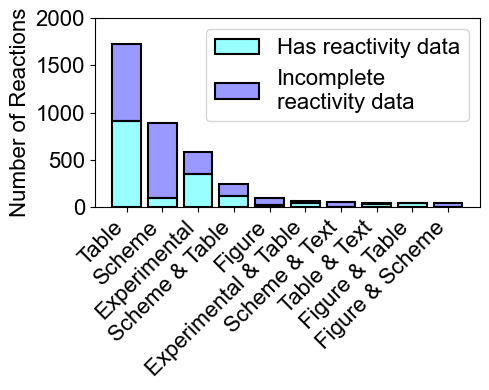


Total reactions with complete reactivity data: 1676
Total reactions: 3878


In [4]:
# Visualize reaction data locations and completeness
plot = Plot(n_rows=1, n_cols=1, figsize=(5, 4), 
            title_fontdict=title_fontdict, 
            label_fontdict={'fontsize': 16}, 
            tick_fontdict={'fontsize': 16}, 
            legend_fontdict={'size': 16})

to_stack = oprd_loc_data[['count', 'has all']].copy()
to_stack = to_stack.sort_values(by='count', ascending=False).head(10)
to_stack['incomplete'] = to_stack['count'] - to_stack['has all']

plot.add_stacked_bar(
    0, 0, 
    categories=to_stack.index, 
    values=[to_stack['has all'].to_list(), to_stack['incomplete'].to_list()],  
    y_label="Number of Reactions", 
    title="", 
    rotation=45, 
    colours=["cyan", "blue"], 
    alpha=0.4, 
    bar_labels=["Has reactivity data", "Incomplete\nreactivity data"], 
    ymax=2000
)

plot.plot(savefig=True, filepath=filepath + "data_location_comparison.png")
print(f"\nTotal reactions with complete reactivity data: {oprd_loc_data['has all'].sum()}")
print(f"Total reactions: {oprd_loc_data['count'].sum()}")

## 2. Yield Types Analysis

This section examines the different types of yield metrics reported in OPRD-100, including isolated yields, assay yields, conversions, and various stereochemical metrics (enantiomeric excess, diastereomeric ratio, etc.).

In [5]:
def json_yield_counts(data, summarize=True, final_step_only=True):
    """Count occurrences of different yield types in the dataset."""
    counts_dict = {
        'Isolated': 0, 'Flow': 0, 'Conversion wrt SM': 0, 'Assay Yield': 0,
        'Selectivity': 0, 'er': 0, 'er R:S': 0, 'er S:R': 0,
        'ee': 0, 'ee (R)': 0, 'ee (S)': 0, 'dr': 0, 'E:Z': 0, 'Z:E': 0,
        'Mass': 0, 'Quantitative': 0, 'No reaction': 0, 'Purity': 0, 'other': 0,
        'No yield info': 0,
    }
    
    summarized_mapping = {
        'Isolated': 'Isolated', 'Flow': 'Flow',
        'Conversion wrt SM': 'Conversion', 'Assay Yield': 'Assay Yield',
        'Selectivity': 'Selectivity',
        'er': 'Enantiomeric Ratio', 'er R:S': 'Enantiomeric Ratio', 'er S:R': 'Enantiomeric Ratio',
        'ee': 'Enantiomeric Excess', 'ee (R)': 'Enantiomeric Excess', 'ee (S)': 'Enantiomeric Excess',
        'dr': 'Diastereomeric Ratio',
        'E:Z': 'E/Z Ratio', 'Z:E': 'E/Z Ratio',
        'Mass': 'Mass', 'Quantitative': 'Quantitative', 'No reaction': 'No reaction',
        'Purity': 'Purity', 'other': 'Other', 'No yield info': 'No yield info',
    }
    
    if summarize:
        counts_dict = {v: 0 for v in sorted(set(summarized_mapping.values()))}
    
    purity_type_counts = defaultdict(int)
    
    for entry in data:
        steps = entry.get("Steps", []) or []
        if not steps:
            continue
        steps_iter = [steps[-1]] if final_step_only else steps
        
        for step in steps_iter:
            y = step.get("Yield", {}) or {}
            if not isinstance(y, dict):
                continue
            
            ptype = y.get("Purity type")
            if _has_value(ptype):
                for pt in ptype if isinstance(ptype, list) else [ptype]:
                    if _has_value(pt):
                        purity_type_counts[pt] += 1
            
            has_yield_info = False
            for k, v in y.items():
                if k == "Purity type":
                    continue
                if _has_value(v):
                    has_yield_info = True
                    target = summarized_mapping.get(k, k) if summarize else k
                    if isinstance(v, list):
                        for i in v:
                            if _has_value(i):
                                counts_dict[target] += 1
                    else:
                        counts_dict[target] += 1
            
            if not has_yield_info:
                counts_dict["No yield info"] += 1
    
    return counts_dict, dict(purity_type_counts)

# Count yield types in OPRD-100
yield_type_counts, purity_counts = json_yield_counts(oprd_100_data, summarize=True, final_step_only=True)
yield_type_counts = dict(sorted(yield_type_counts.items(), key=lambda item: item[1], reverse=True))

print("Yield Types in OPRD-100:")
for yield_type, count in yield_type_counts.items():
    print(f"  {yield_type}: {count}")

Yield Types in OPRD-100:
  Isolated: 1592
  Assay Yield: 1066
  No yield info: 583
  Conversion: 550
  Mass: 500
  Other: 410
  Purity: 316
  Selectivity: 308
  No reaction: 161
  Enantiomeric Excess: 145
  Enantiomeric Ratio: 73
  Diastereomeric Ratio: 65
  E/Z Ratio: 19
  Quantitative: 8
  Flow: 2


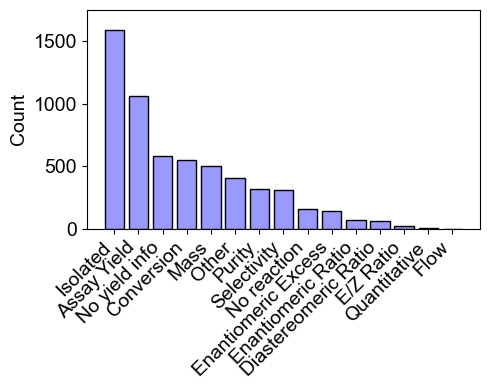

In [6]:
# Visualize yield types distribution
plot = Plot(n_rows=1, n_cols=1, figsize=(5, 4), 
            title_fontdict=title_fontdict, 
            label_fontdict=label_fontdict, 
            tick_fontdict=tick_fontdict, 
            legend_fontdict=legend_fontdict)

plot.add_bar(
    0, 0, 
    list(yield_type_counts.keys()),
    yield_type_counts.values(),
    rotation=45,
    colour="blue", 
    alpha=0.4,
    bar_edgecolor=["black"], 
    bar_edgewidth=[1.0],
    title="",
    y_label="Count", 
    ymax=1750
)

plot.plot(savefig=True, filepath=filepath + "yield_types_OPRD-100.png")

## 3. Yield Distribution Analysis

This section analyzes the distribution of yield values across different data locations (schemes, tables, experimental sections) to understand typical yield ranges and reporting patterns.

In [7]:
def _to_float(x):
    """Convert a single token to float, handling various formats."""
    if isinstance(x, (int, float)) and not isinstance(x, bool):
        if isinstance(x, float) and math.isnan(x):
            return None
        return float(x)
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return None
        s = s.replace('%', '')
        s = re.sub(r'^[<>=~]+', '', s)
        s = re.sub(r'\bpercent\b', '', s, flags=re.I)
        s = s.strip()
        if not s:
            return None
        try:
            return float(s)
        except ValueError:
            return None
    return None

def json_yield_data(data, collect_by_location=False, data_locations=None, 
                    summarize=True, final_step_only=True):
    """Extract numerical yield data from the dataset."""
    summarized_mapping = {
        'Isolated': 'Isolated',
        'Conversion wrt SM': 'Conversion',
        'Assay Yield': 'Assay Yield',
        'ee': 'Enantiomeric Excess',
        'ee (R)': 'Enantiomeric Excess',
        'ee (S)': 'Enantiomeric Excess',
        'Mass': 'Mass',
        'Purity': 'Purity'
    }
    counts_dict = {v: [] for v in sorted(set(summarized_mapping.values()))}
    
    for entry in data:
        if collect_by_location:
            loc = entry.get("Location")
            loc_type = ""
            if isinstance(loc, dict):
                t = loc.get("Type")
                if isinstance(t, (list, tuple)):
                    loc_type = " ".join(str(x) for x in t)
                elif isinstance(t, str):
                    loc_type = t
            elif isinstance(loc, str):
                loc_type = loc
            
            if data_locations:
                if data_locations == ["Table"]:
                    if not re.search(r'\btable\b', loc_type, flags=re.I):
                        continue
                else:
                    if not any(dl.lower().strip() == loc_type.lower().strip() for dl in data_locations):
                        continue
        
        steps = entry.get("Steps", []) or []
        if not steps:
            continue
        step_list = [steps[-1]] if final_step_only else steps
        
        for step in step_list:
            y = step.get("Yield", {}) or {}
            if not isinstance(y, dict):
                continue
            
            for k, v in y.items():
                if not _has_value(v):
                    continue
                
                if k == "Quantitative":
                    counts_dict["Assay Yield"].append(100.0)
                    continue
                if k == "No reaction":
                    counts_dict["Assay Yield"].append(0.0)
                    continue
                
                target = summarized_mapping.get(k)
                if target and target in counts_dict and target != "Mass":
                    if isinstance(v, (list, tuple, set)):
                        for item in v:
                            f = _to_float(item)
                            if f is not None:
                                counts_dict[target].append(f)
                    else:
                        f = _to_float(v)
                        if f is not None:
                            counts_dict[target].append(f)
    
    return counts_dict

# Collect yield data by location
yields_schemes = json_yield_data(oprd_100_data, summarize=True, collect_by_location=True, 
                                 data_locations=["Scheme"])
yields_tables = json_yield_data(oprd_100_data, summarize=True, collect_by_location=True, 
                                data_locations=["Table"])
yields_experimental = json_yield_data(oprd_100_data, summarize=True, collect_by_location=True, 
                                      data_locations=["Experimental"])

print(f"Schemes - Isolated yields: {len(yields_schemes['Isolated'])}")
print(f"Tables - Assay yields: {len(yields_tables['Assay Yield'])}")
print(f"Experimental - Isolated yields: {len(yields_experimental['Isolated'])}")

Schemes - Isolated yields: 491
Tables - Assay yields: 1173
Experimental - Isolated yields: 515


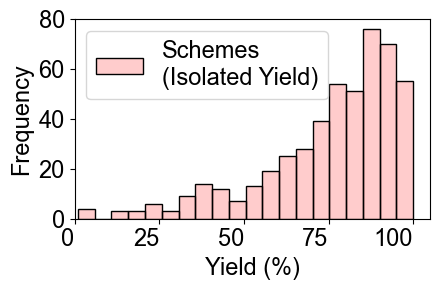

In [8]:
# Plot yield distributions for schemes
plot = Plot(n_rows=1, n_cols=1, figsize=(4.5, 3), 
            title_fontdict={'fontsize': 17}, 
            label_fontdict={'fontsize': 17}, 
            tick_fontdict={'fontsize': 17}, 
            legend_fontdict={'size': 17})

plot.add_hist(
    0, 0, 
    data=yields_schemes["Isolated"],
    bins=20,
    rotation=0,
    colour="red", 
    alpha=0.2,
    label="Schemes\n(Isolated Yield)",
    bar_edgecolor=["black"], 
    bar_edgewidth=[1.0],
    y_label="Frequency", 
    x_label="Yield (%)", 
    ymax=80
)

plot.plot(savefig=True, filepath=filepath + "OPRD-100_schemes_yield_dist.png")

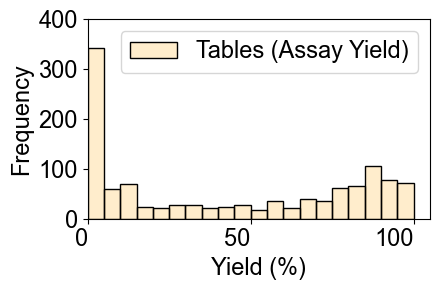

In [9]:
# Plot yield distributions for tables
plot = Plot(n_rows=1, n_cols=1, figsize=(4.5, 3), 
            title_fontdict={'fontsize': 17}, 
            label_fontdict={'fontsize': 17}, 
            tick_fontdict={'fontsize': 17}, 
            legend_fontdict={'size': 17})

plot.add_hist(
    0, 0, 
    data=yields_tables["Assay Yield"],
    bins=20,
    rotation=0,
    colour="orange", 
    alpha=0.2,
    label="Tables (Assay Yield)",
    bar_edgecolor=["black"], 
    bar_edgewidth=[1.0],
    y_label="Frequency", 
    x_label="Yield (%)", 
    overlay=True, 
    ymax=400
)

plot.plot(savefig=True, filepath=filepath + "OPRD-100_tables_yield_dist.png")

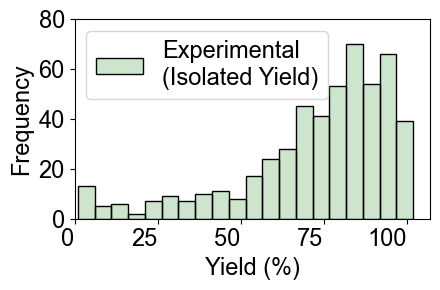

In [10]:
# Plot yield distributions for experimental sections
plot = Plot(n_rows=1, n_cols=1, figsize=(4.5, 3), 
            title_fontdict={'fontsize': 17}, 
            label_fontdict={'fontsize': 17}, 
            tick_fontdict={'fontsize': 17}, 
            legend_fontdict={'size': 17})

plot.add_hist(
    0, 0, 
    data=yields_experimental["Isolated"],
    bins=20,
    rotation=0,
    colour="green", 
    alpha=0.2,
    label="Experimental\n(Isolated Yield)",
    bar_edgecolor=["black"], 
    bar_edgewidth=[1.0],
    x_label="Yield (%)",
    title="",
    y_label="Frequency", 
    overlay=True, 
    ymax=80
)

plot.plot(savefig=True, filepath=filepath + "OPRD-100_experimental_yield_dist.png")

## 4. Stereochemistry Analysis

This section analyzes stereogenic centers in OPRD-100 reactions, examining how many stereogenic centers are gained, lost, or preserved during reactions, and what percentage have associated stereochemical yield data (e.g., enantiomeric excess).

The ReactionParser analyzes each reaction SMILES to identify stereogenic elements (R/S chiral centers, E/Z double bonds) and tracks their fate through the reaction.

In [11]:
# Run stereochemistry analysis using ReactionParser
# Note: This analysis is computationally intensive (relies on atom-atom mapping) and may take several minutes

print("Initializing ReactionParser with OPRD-100 data...")
rp = ReactionParser("../data/OPRD-100.json")

print("Analyzing stereochemistry changes across all reactions...")
print("This will track gained, lost, and preserved stereogenic centers...")
print("(This may take a few minutes to complete)\n")

# Count stereochemistry changes
# unique_only=False: count all stereocenters, not just unique ones
# yield_check=True: identify which reactions have stereochemical yield data (ee, dr, etc.)
gained, lost, unchanged, g_hy, l_hy, u_hy = rp.count_stereochemistry_changes(
    unique_only=False, 
    yield_check=True
)

print("\nStereochemistry Analysis Results:")
print(f"\nStereogenic centers GAINED in products:")
for stereo_type, count in sorted(gained.items(), key=lambda x: x[1], reverse=True):
    print(f"  {stereo_type}: {count}")

print(f"\nStereogenic centers LOST from reactants:")
for stereo_type, count in sorted(lost.items(), key=lambda x: x[1], reverse=True):
    print(f"  {stereo_type}: {count}")

print(f"\nStereogenic centers PRESERVED (unchanged):")
for stereo_type, count in sorted(unchanged.items(), key=lambda x: x[1], reverse=True):
    print(f"  {stereo_type}: {count}")

print(f"\nReactions with stereochemical yields (gained centers):")
for stereo_type, count in sorted(g_hy.items(), key=lambda x: x[1], reverse=True):
    print(f"  {stereo_type}: {count}")

# Calculate percentages
total_cc_bonds_gained = gained.get('E', 0) + gained.get('Z', 0) + gained.get('Unspecified Double Bond', 0)
cc_bonds_with_yield = g_hy.get('E', 0) + g_hy.get('Z', 0) + g_hy.get('Unspecified Double Bond', 0)

total_chiral_centers_gained = gained.get('R', 0) + gained.get('S', 0) + gained.get('Unspecified Tetrahedral Atom', 0)
chiral_centers_with_yield = g_hy.get('R', 0) + g_hy.get('S', 0) + g_hy.get('Unspecified Tetrahedral Atom', 0)

if total_cc_bonds_gained > 0:
    cc_bonds_with_stereo_yield = cc_bonds_with_yield / total_cc_bonds_gained
    print(f"\n% of C=C bonds with stereochemical yields: {cc_bonds_with_stereo_yield:.1%}")

if total_chiral_centers_gained > 0:
    chiral_centers_with_stereo_yield = chiral_centers_with_yield / total_chiral_centers_gained
    print(f"% of chiral centers with stereochemical yields: {chiral_centers_with_stereo_yield:.1%}")

Initializing ReactionParser with OPRD-100 data...
Analyzing stereochemistry changes across all reactions...
This will track gained, lost, and preserved stereogenic centers...
(This may take a few minutes to complete)

An error occurred while processing an entry: [CH3:1][C:2]([CH:3]([CH2:4][CH:5]([CH3:6])[CH3:27])[Br:10])=[O:8]>>[CH3:1]/[C:2](=[CH:3]/[CH2:4][CH:5]([CH3:6])[CH3:7])[O:8][P:9]([Br:10])([c:11]1[cH:12][cH:13][cH:14][cH:15][cH:16]1)([c:17]1[cH:18][cH:19][cH:20][cH:21][cH:22]1)[c:23]1[cH:24][cH:25][cH:26][cH:27][cH:28]1
An error occurred while processing an entry: I[c:3]1[cH:4][cH:5][cH:6][cH:7][cH:8]1.N#[C][Fe]([C]#N)([C]#N)([C]#N)([C]#N)[C:2]#[N:1].[K].[K].[K].[K]>>[N:1]#[C:2][c:3]1[cH:4][cH:5][cH:6][cH:7][cH:8]1
An error occurred while processing an entry: I[c:3]1[cH:4][cH:5][cH:6][cH:7][cH:8]1.N#[C][Fe]([C]#N)([C]#N)([C]#N)([C]#N)[C:2]#[N:1].[K].[K].[K].[K]>>[N:1]#[C:2][c:3]1[cH:4][cH:5][cH:6][cH:7][cH:8]1
An error occurred while processing an entry: I[c:3]1[cH:4][cH:5][cH

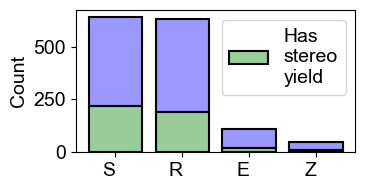

In [12]:
# Visualize stereochemistry changes
do_drop = ['Unspecified Tetrahedral Atom', 'Unspecified Double Bond', 
           'unspecified Fused-ring', 's', 'r']

plot = Plot(n_rows=1, n_cols=1, figsize=(3.755, 2), 
            title_fontdict=title_fontdict,
            label_fontdict=label_fontdict, 
            tick_fontdict=tick_fontdict,
            legend_fontdict=legend_fontdict)

to_stack = (
    pd.DataFrame({'gained': gained})
    .join(pd.DataFrame({'g_hy': g_hy}), how='outer')
    .fillna(0)
    .astype(int)
    .sort_values('gained', ascending=False)
)
to_stack['gained'] = to_stack['gained'] - to_stack['g_hy']
to_stack = to_stack[~to_stack.index.isin(do_drop)]

plot.add_stacked_bar(
    0, 0, 
    categories=to_stack.index, 
    values=[to_stack['g_hy'].to_list(), to_stack['gained'].to_list()], 
    y_label="Count", 
    title="", 
    rotation=0, 
    colours=["green", "blue"], 
    alpha=0.4,
    bar_labels=["Has\nstereo\nyield", ""]
)

plot.plot(savefig=True, filepath=filepath + "stereocentre_changes_OPRD-100.png")

## 5. Solvent Usage and Environmental Assessment

This section analyzes solvent usage in OPRD-100 reactions, including frequency of use, volumes, and environmental classification according to CHEM21 solvent selection guidelines.

Total unique solvent strings: 284 (new lookups: 0)


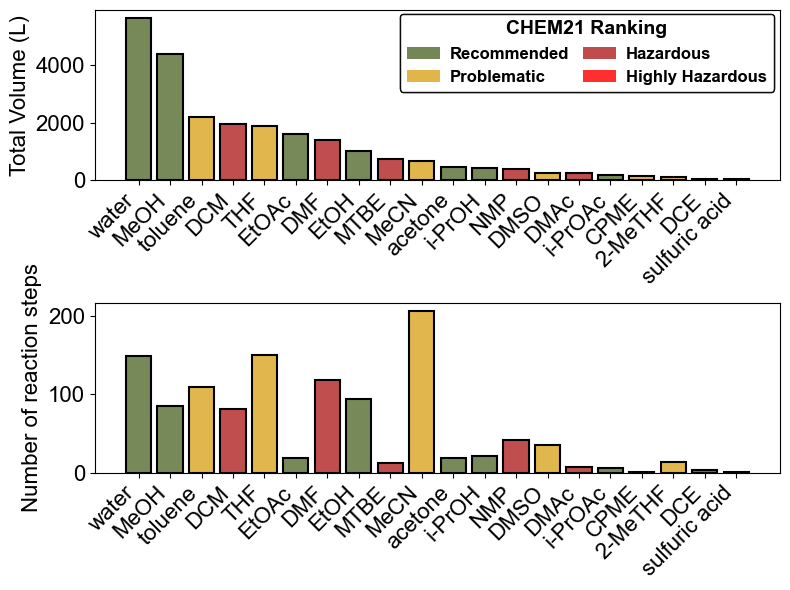

In [15]:
# ---------- Faster volume extraction (precompile regex) ----------
_VOL_SPLIT = re.compile(r'\s*\+\s*')
_VOL_PATTERN = re.compile(r'(\d*\.?\d+)\s*(µL|μL|uL|mL|L)\b')

def _extract_volume(val):
    if not val:
        return None
    parts = _VOL_SPLIT.split(val) if isinstance(val, str) else val
    total = 0.0
    for p in parts:
        m = _VOL_PATTERN.search(p)
        if not m:
            continue
        num = float(m.group(1))
        unit = m.group(2)
        if unit in ("µL", "μL", "uL"):
            num /= 1000.0
        elif unit == "L":
            num *= 1000.0
        total += num
    return total if total > 0 else None

# ---------- Solvent standardisation acceleration ----------

_BRACKETS = re.compile(r'\s*\(.*?\)\s*')
_SLASH_SPLIT = re.compile(r'\s*/\s*')

def _normalize_raw_solvent_name(raw):
    if not isinstance(raw, str):
        return None
    s = _BRACKETS.sub(' ', raw).strip()
    s = re.sub(r'\s+', ' ', s)
    return s if s else None

def collect_unique_solvent_names(data):
    names = set()
    for entry in data:
        for step in entry.get("Steps", []) or []:
            solvents = step.get("Solvents", []) or []
            if not isinstance(solvents, list):
                continue
            for solvent in solvents:
                nm = _normalize_raw_solvent_name(solvent.get("Solvent"))
                if nm:
                    names.add(nm)
    return names

def build_solvent_standardization_map(unique_names,
                                      cache_file="solvent_standardization_cache.json",
                                      split_components=True,
                                      join_token=" / ",
                                      verbose=True):
    """
    Build (or load) a mapping: raw_name -> standardized_name.
    PubChem is queried once per (component) name; results cached on disk.
    """
    try:
        import pubchempy as pcp
    except ImportError:
        if verbose:
            print("pubchempy not installed; returning identity mapping.")
        return {n: n for n in unique_names}

    disk_cache = {}
    if cache_file and os.path.exists(cache_file):
        try:
            with open(cache_file, 'r') as f:
                disk_cache = json.load(f)
        except Exception:
            disk_cache = {}

    mapping = {}
    comp_cache = {}  # component-level cache to avoid repeated lookups

    def std_component(comp):
        c = comp.strip()
        if not c:
            return c
        if c in comp_cache:
            return comp_cache[c]
        try:
            hits = pcp.get_compounds(c, 'name')
            if hits:
                comp_cache[c] = hits[0].iupac_name
            else:
                comp_cache[c] = c
        except Exception:
            comp_cache[c] = c
        return comp_cache[c]

    to_lookup = [n for n in unique_names if n not in disk_cache]
    if verbose:
        print(f"Total unique solvent strings: {len(unique_names)} (new lookups: {len(to_lookup)})")

    for i, raw in enumerate(to_lookup, 1):
        if split_components and "/" in raw:
            parts = _SLASH_SPLIT.split(raw)
            std_parts = [std_component(p) for p in parts]
            standardized = join_token + join_token.join(std_parts) if join_token.strip() else "/".join(std_parts)
            # Clean accidental double join_token
            standardized = re.sub(r'(?:\s*/\s*){2,}', '/', standardized)
        else:
            standardized = std_component(raw)
        disk_cache[raw] = standardized
        if verbose and i % 25 == 0:
            print(f"Processed {i}/{len(to_lookup)} solvent names")

    # Persist cache
    if cache_file:
        try:
            with open(cache_file, 'w') as f:
                json.dump(disk_cache, f, indent=2)
        except Exception as e:
            if verbose:
                print(f"Failed to write cache: {e}")

    # Final mapping
    mapping.update(disk_cache)
    return mapping

def count_solvents_fast(data,
                        cache_file="../src/solvent_standardization_cache.json",
                        split_components=True):
    """
    Optimized solvent counting using a precomputed name standardization map.
    """
    unique = collect_unique_solvent_names(data)
    std_map = build_solvent_standardization_map(unique,
                                                cache_file=cache_file,
                                                split_components=split_components)
    solvent_counts = defaultdict(int)
    solvent_volumes = defaultdict(int)

    solvents_with_volume = defaultdict(int)

    for entry in data:
        for step in entry.get("Steps", []) or []:
            solvents = step.get("Solvents", []) or []
            if not isinstance(solvents, list):
                continue
            for solvent in solvents:
                raw_name = _normalize_raw_solvent_name(solvent.get("Solvent"))
                if not raw_name:
                    continue
                std_name = std_map.get(raw_name, raw_name)
                solvent_counts[std_name] += 1
                amts = solvent.get("Amounts") or {}
                vol_str = amts.get("Volume")
                if vol_str:
                    vol = _extract_volume(vol_str) 
                    if vol:
                        solvent_volumes[std_name] += vol / 1000.0  # convert mL to L
                        solvents_with_volume[std_name] += 1

    return dict(solvent_counts), dict(solvent_volumes), dict(solvents_with_volume)

oprd_solvent_counts, oprd_solvent_volumes, oprd_solvents_with_volume = count_solvents_fast(oprd_100_data)

ranking_colors = {
        'Recommended': 'darkolivegreen',
        'Problematic': 'goldenrod',
        'Hazardous': 'firebrick',
        'Highly Hazardous': 'red',
        'Not Listed': "grey",
    }

severity_order = {
        'Highly Hazardous': 4,
        'Hazardous': 3,
        'Problematic': 2,
        'Recommended': 1,
        'Not Listed': 0,
    }

oprd_solvent_volumes_df = pd.DataFrame.from_dict(oprd_solvent_volumes, orient='index', columns=['Volume (L)'])
oprd_solvent_volumes_df = oprd_solvent_volumes_df.sort_values(by='Volume (L)', ascending=False)

chem_21_data = json_to_dict("../src/CHEM21_solvent_dict.json")

def _norm(s: str) -> str:
    return re.sub(r'\s+', ' ', s.strip()).lower()

def build_name_to_ranking(chem_21_data, severity_order):
    """
    Build a case-insensitive lookup: normalized name -> ranking.
    If multiple entries map to the same normalized token, keep the worst (highest severity).
    """
    lookup = {}
    for key, info in chem_21_data.items():
        ranking = info.get("ranking", "Not Listed") or "Not Listed"
        preferred = info.get("preferred_name") or key
        synonyms_list = info.get("synonyms", []) or []
        candidates = {key, preferred}
        candidates.update(synonyms_list)
        for raw in candidates:
            if not raw:
                continue
            n = _norm(raw)
            existing = lookup.get(n)
            if (existing is None) or (severity_order.get(ranking, 0) > severity_order.get(existing, 0)):
                lookup[n] = ranking
    return lookup

name_to_ranking = build_name_to_ranking(chem_21_data, severity_order)

def worst_ranking_for_composite(name: str) -> str:
    """
    For solvent strings containing component separators '/', evaluate each component
    and return the worst (highest severity) ranking.
    """
    parts = [p for p in re.split(r'\s*/\s*', name) if p.strip()]
    if not parts:
        return "Not Listed"
    best = "Not Listed"
    best_score = 0
    for p in parts:
        rk = name_to_ranking.get(_norm(p), "Not Listed")
        sc = severity_order.get(rk, 0)
        if sc > best_score:
            best_score = sc
            best = rk
    return best

colours = []
solvent_rankings = []
unmatched = []

for solvent in oprd_solvent_volumes_df.index:
    ranking = name_to_ranking.get(_norm(solvent))
    if ranking is None:
        # Try composite worst-case
        if '/' in solvent:
            ranking = worst_ranking_for_composite(solvent)
        else:
            ranking = "Not Listed"
        if ranking == "Not Listed":
            unmatched.append(solvent)
    solvent_rankings.append(ranking)
    colours.append(ranking_colors.get(ranking, "grey"))

# Optional: attach ranking & colour to the dataframe for inspection
oprd_solvent_volumes_df["Ranking"] = solvent_rankings
oprd_solvent_volumes_df["Colour"] = colours

# get solventcounts into a dataframe
oprd_solvent_with_volume_counts_df = pd.DataFrame.from_dict(oprd_solvents_with_volume, orient='index', columns=['Count'])
# sort by oprd_solvent_volumes_df index
oprd_solvent_with_volume_counts_df = oprd_solvent_with_volume_counts_df.reindex(oprd_solvent_volumes_df.index)


# Plot the top 20 solvents by volume with color coding by ranking
plot = Plot(n_rows=2, n_cols=1, figsize=(8, 6), title_fontdict={'fontsize': 18, 'fontweight': 'bold'},
             label_fontdict={'fontsize': 16,}, tick_fontdict={'fontsize': 16, 'fontweight': 'bold'},
               legend_fontdict={'size': 16,})

plot.add_bar(1,0,categories=oprd_solvent_with_volume_counts_df.head(20).index, values=oprd_solvent_with_volume_counts_df.head(20)['Count'].to_list(), y_label="Number of reaction steps", title="", rotation=45, colour=oprd_solvent_volumes_df['Colour'].to_list(), alpha=0.8, colspan=2)

plot.add_bar(0,0,categories=oprd_solvent_volumes_df.head(20).index, values=oprd_solvent_volumes_df.head(20)['Volume (L)'].to_list(), 
                      y_label="Total Volume (L)", title="", rotation=45, colour=oprd_solvent_volumes_df['Colour'].to_list(), alpha=0.8, colspan=2)

entries = [
    {'label': 'Recommended', 'color': 'darkolivegreen', 'alpha': 0.8, 'fontsize': 14,},
    {'label': 'Problematic', 'color': 'goldenrod', 'alpha': 0.8, 'fontsize': 14,},
    {'label': 'Hazardous', 'color': 'firebrick', 'alpha': 0.8, 'fontsize': 14,},
    {'label': 'Highly Hazardous', 'color': 'red', 'alpha': 0.8, 'fontsize': 14,},
    #{'label': 'Not Listed', 'color': 'grey', 'alpha': 0.8, 'fontsize': 14,},
]

plot.add_figure_legend(
    entries,
    title="CHEM21 Ranking",
    title_fontsize=14,
    anchor=(0.74, 0.825),   # centered at bottom of the entire figure
    loc='lower center',
    frame=True,
    frame_facecolor='white',
    frame_alpha=0.9,
    frame_edgecolor='black',
    ncol=2,
    label_fontsize=12,
    label_fontweight='bold'
)

# add a pie_chart of the total volumes of each colour
total_volumes = defaultdict(float)
for idx, row in oprd_solvent_volumes_df.iterrows():
    total_volumes[row['Ranking']] += row['Volume (L)']
total_volumes = dict(total_volumes)

values = list(total_volumes.values())
labels = list(total_volumes.keys())
colours = [ranking_colors.get(k, "grey") for k in labels]

def interleave_large_small(values, labels, colours):
    """
    Reorder so large and small slices alternate: L1, S1, L2, S2, ...
    Helps reduce clustering of tiny labels.
    """
    if len(values) <= 3:
        return values, labels, colours  # not worth reordering

    # Sort indices by value descending
    idx_sorted = sorted(range(len(values)), key=lambda i: values[i], reverse=True)
    # Two-pointer walk: largest, smallest, next largest, next smallest ...
    ordered_idx = []
    left, right = 0, len(idx_sorted) - 1
    toggle = True
    while left <= right:
        if toggle:
            ordered_idx.append(idx_sorted[left])
            left += 1
        else:
            ordered_idx.append(idx_sorted[right])
            right -= 1
        toggle = not toggle

    vals_new   = [values[i] for i in ordered_idx]
    labels_new = [labels[i] for i in ordered_idx]
    cols_new   = [colours[i] for i in ordered_idx]
    return vals_new, labels_new, cols_new

values, labels, colours = interleave_large_small(values, labels, colours)

# plot.add_pie(
#     0, 2,
#     values=values,
#     #labels=labels,
#     colours=colours,
#     alpha=[0.8]*len(total_volumes),
#     small_slice_threshold=0.06,   # slices <6% moved outside
#     outside_distance=1,        # how far from center
#     outside_alignment='right',    # 'right','left','center'
#     title="Proportion of Total Solvent Volume\n by CHEM21 Ranking",
#     #autopct="%1.0f%%",
#     startangle=90,
#     radius=0.3

    
# )

plot.plot(savefig=False, filepath=filepath + "oprd-100_solvent_usage_chem21_ranking.png")


## 6. Reaction Conditions: Time Distribution

This section analyzes the distribution of reaction times in OPRD-100, converting various time formats to hours for comparison.

In [16]:
# Time parsing utilities
_UNIT_MAP = {
    'd': 24.0, 'day': 24.0, 'days': 24.0,
    'h': 1.0, 'hr': 1.0, 'hrs': 1.0, 'hour': 1.0, 'hours': 1.0,
    'm': 1/60.0, 'min': 1/60.0, 'mins': 1/60.0, 'minute': 1/60.0, 'minutes': 1/60.0,
    's': 1/3600.0, 'sec': 1/3600.0, 'secs': 1/3600.0, 'second': 1/3600.0, 'seconds': 1/3600.0
}

_RANGE_RE = re.compile(
    r'(\d+(?:\.\d+)?)\s*(?:-|to)\s*(\d+(?:\.\d+)?)\s*(d|day|days|h|hr|hrs|hour|hours|m|min|mins|minute|minutes|s|sec|secs|second|seconds)\b', 
    re.I
)
_PAIR_RE = re.compile(
    r'(\d+(?:\.\d+)?)\s*(d|day|days|h|hr|hrs|hour|hours|m|min|mins|minute|minutes|s|sec|secs|second|seconds)\b', 
    re.I
)

def _parse_time_fragment(fragment: str):
    """Parse a single time fragment into hours."""
    frag = fragment.strip().lower()
    if not frag:
        return None
    
    total = 0.0
    consumed = False
    
    # Handle ranges (take average)
    for rm in _RANGE_RE.finditer(frag):
        v1 = float(rm.group(1))
        v2 = float(rm.group(2))
        unit = rm.group(3).lower()
        mult = _UNIT_MAP.get(unit)
        if mult:
            total += ((v1 + v2) / 2.0) * mult
            consumed = True
    
    frag_clean = _RANGE_RE.sub(' ', frag)
    
    # Handle single values with units
    tokens = _PAIR_RE.findall(frag_clean)
    if tokens:
        for val, unit in tokens:
            mult = _UNIT_MAP.get(unit.lower())
            if mult:
                total += float(val) * mult
                consumed = True
    
    # Handle compact format like "5h30"
    compact = re.findall(r'(\d+)h(\d+)$', frag_clean.replace(' ', ''))
    if compact:
        for h, m in compact:
            total += float(h) * 1.0 + float(m) * (1/60.0)
            consumed = True
    
    return total if consumed else None

def convert_to_hours(raw: str):
    """Convert time string to hours, handling multiple values separated by '+'."""
    if not isinstance(raw, str):
        return None
    parts = re.split(r'\s*\+\s*', raw)
    total = 0.0
    got = False
    for p in parts:
        val = _parse_time_fragment(p)
        if val is not None:
            total += val
            got = True
    return total if got else None

def collect_times(data):
    """Collect all reaction times from dataset."""
    times = []
    for entry in data:
        for step in entry.get("Steps", []) or []:
            t = step.get("Time")
            if not t:
                continue
            val = convert_to_hours(t)
            if val is not None:
                times.append(val)
    return times

collected_times = collect_times(oprd_100_data)
collected_times = [t for t in collected_times if t is not None and t < 55]

print(f"Number of reaction times collected: {len(collected_times)}")
print(f"Mean reaction time: {np.mean(collected_times):.2f} hours")
print(f"Median reaction time: {np.median(collected_times):.2f} hours")

Number of reaction times collected: 2879
Mean reaction time: 9.30 hours
Median reaction time: 5.00 hours


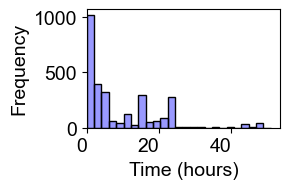

In [17]:
# Plot reaction time distribution
plot = Plot(n_rows=1, n_cols=1, figsize=(3, 2), 
            title_fontdict=title_fontdict,
            label_fontdict=label_fontdict, 
            tick_fontdict=tick_fontdict,
            legend_fontdict=legend_fontdict)

plot.add_hist(
    0, 0, 
    data=collected_times,
    bins=25,
    rotation=0,
    colour="blue", 
    alpha=0.4,
    bar_edgecolor=["black"], 
    bar_edgewidth=[1.0],
    title="",
    x_label="Time (hours)",
    y_label="Frequency"
)

plot.plot(savefig=True, filepath=filepath + "reaction_time_distribution_OPRD-100.png")

## 7. Reaction Conditions: Temperature Distribution

This section analyzes the distribution of reaction temperatures in OPRD-100, handling various temperature formats and keywords (e.g., "room temperature", "reflux").

In [18]:
# Temperature parsing utilities
_TEMP_RANGE_RE = re.compile(
    r'(?P<t1>-?\d+(?:\.\d+)?)\s*(?:to|–|—|-)\s*(?P<t2>-?\d+(?:\.\d+)?)\s*(?:°?\s*C|deg\s*C|degrees?\s*C)\b',
    re.I
)
_TEMP_SINGLE_RE = re.compile(
    r'(?P<t>-?\d+(?:\.\d+)?)\s*(?:°?\s*C|deg\s*C|degrees?\s*C)\b',
    re.I
)

# Keyword to temperature mapping
_KEYWORD_TEMPS = {
    'rt': 25.0,
    'r.t.': 25.0,
    'room temperature': 25.0,
    'ambient': 25.0,
    'ambient temperature': 25.0,
    'ice bath': 0.0,
    'cold': 5.0,
    'cool': 5.0
}
_KEYWORD_PATTERNS = [(re.compile(r'\b' + re.escape(k) + r'\b', re.I), v) 
                     for k, v in _KEYWORD_TEMPS.items()]

def _normalize_temp_string(s: str) -> str:
    """Normalize temperature string."""
    if not isinstance(s, str):
        return ""
    s = s.replace('–', '-').replace('—', '-').replace('−', '-')
    s = s.replace('\u00b0', '°')
    return re.sub(r'\s+', ' ', s.strip())

def parse_temperature_tokens(raw: str, average_range_if_span_lt: float = 25.0,
                            keep_large_range_ends: bool = True):
    """Extract numeric Celsius values from temperature string."""
    if not isinstance(raw, str):
        return []
    s = _normalize_temp_string(raw.lower())
    
    # Skip reflux
    if re.search(r'\breflux\b', s):
        return []
    
    values = []
    
    # Handle textual keywords
    for pat, val in _KEYWORD_PATTERNS:
        if pat.search(s):
            values.append(val)
            s = pat.sub(' ', s)
    
    # Handle temperature ranges
    for m in _TEMP_RANGE_RE.finditer(s):
        t1 = float(m.group('t1'))
        t2 = float(m.group('t2'))
        span = abs(t1 - t2)
        if span < average_range_if_span_lt:
            values.append((t1 + t2) / 2.0)
        elif keep_large_range_ends:
            values.extend([t1, t2])
    
    # Remove ranges to prevent double counting
    s_clean = _TEMP_RANGE_RE.sub(' ', s)
    
    # Handle single temperatures
    for m in _TEMP_SINGLE_RE.finditer(s_clean):
        values.append(float(m.group('t')))
    
    # Deduplicate
    seen = set()
    deduped = []
    for v in values:
        if v not in seen:
            seen.add(v)
            deduped.append(v)
    return deduped

def collect_temperatures(data):
    """Collect all reaction temperatures from dataset."""
    temps = []
    for entry in data:
        for step in entry.get("Steps", []) or []:
            raw_t = step.get("Temperature")
            if not raw_t:
                continue
            parsed = parse_temperature_tokens(raw_t)
            if not parsed:
                continue
            temps.extend(parsed)
    return temps

collected_temperatures = collect_temperatures(oprd_100_data)
collected_temperatures = [t for t in collected_temperatures if -120 <= t <= 250]

print(f"Number of temperatures collected: {len(collected_temperatures)}")
print(f"Mean temperature: {np.mean(collected_temperatures):.1f} °C")
print(f"Median temperature: {np.median(collected_temperatures):.1f} °C")

Number of temperatures collected: 3018
Mean temperature: 47.7 °C
Median temperature: 40.0 °C


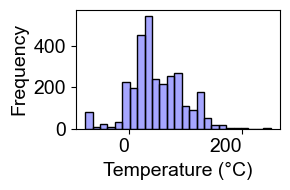

In [19]:
# Plot temperature distribution
plot = Plot(n_rows=1, n_cols=1, figsize=(3, 2),
            title_fontdict=title_fontdict,
            label_fontdict=label_fontdict,
            tick_fontdict=tick_fontdict,
            legend_fontdict=legend_fontdict)

plot.add_hist(
    0, 0,
    data=collected_temperatures,
    bins=25,
    rotation=0,
    colour="blue", 
    alpha=0.35,
    bar_edgecolor=["black"], 
    bar_edgewidth=[1.0],
    title="",
    x_label="Temperature (°C)",
    y_label="Frequency", 
    start_x_at_zero=False
)

plot.plot(savefig=True, filepath=filepath + "reaction_temperature_distribution_OPRD-100.png")

## 8. Catalyst Usage Analysis

This section identifies and quantifies the use of different metal catalysts in OPRD-100 reactions, providing insights into common catalytic systems in process chemistry.

In [20]:
def find_catalysts(data):
    catalysts = {
        'Palladium': ["Pd", "Palladium", "palladium"],
        'Platinum': ["Pt", "Platinum", "platinum"],
        'Rhodium': ["Rh", "Rhodium", "rhodium"],
        'Ruthenium': ["Ru", "Ruthenium", "ruthenium"],
        'Iridium': ["Ir", "Iridium", "iridium"],
        'Nickel': ["Ni", "Nickel", "nickel"],
        'Copper': ["Cu", "Copper", "copper"],
        'Cobalt': ["Co", "Cobalt", "cobalt"],
        'Iron': ["Fe", "Iron", "ferrous", "ferric", "iron"],
        'Titanium': ["Ti", "Titanium", "titanium"],
        'Zinc': ["Zn", "Zinc", "zinc"],
        'Manganese': ["Mn", "Manganese", "manganese"],
        'Lithium': ["Li", "Lithium", "lithium"],
    }
    found_catalysts = defaultdict(int)
    reactions = []
    for entry in data:
        smiles = entry.get("Reaction")
        for cat, keywords in catalysts.items():
            kw = keywords[0]  # Use only the first keyword for SMILES search
            if re.search(kw, smiles):
                    found_catalysts[cat] += 1
                    reactions.append(entry)
                    continue  # Avoid double counting from SMILES and reagents
        for step in entry.get("Steps", []) or []:
            reagents= step.get("Reagents") or []
            for reagent in reagents:
                name = reagent.get("Reagent") or ""
                for cat, keywords in catalysts.items():
                    for kw in keywords:
                        if re.search(kw, name):
                            found_catalysts[cat] += 1
                            reactions.append(entry)
            
    return dict(sorted(found_catalysts.items(), key=lambda x: x[1], reverse=True)), reactions

catalyst_counts, reactions = find_catalysts(oprd_100_data)

catalyst_counts, reactions_with_catalysts = find_catalysts(oprd_100_data)

print("Catalyst Usage in OPRD-100:")
for catalyst, count in catalyst_counts.items():
    print(f"  {catalyst}: {count}")
print(f"\nTotal catalyst instances: {sum(catalyst_counts.values())}")
print(f"Reactions with catalysts: {len(reactions_with_catalysts)}")

Catalyst Usage in OPRD-100:
  Palladium: 489
  Lithium: 169
  Copper: 169
  Ruthenium: 166
  Zinc: 122
  Nickel: 70
  Manganese: 51
  Iron: 46
  Rhodium: 45
  Platinum: 22
  Cobalt: 8
  Titanium: 5
  Iridium: 4

Total catalyst instances: 1366
Reactions with catalysts: 1366


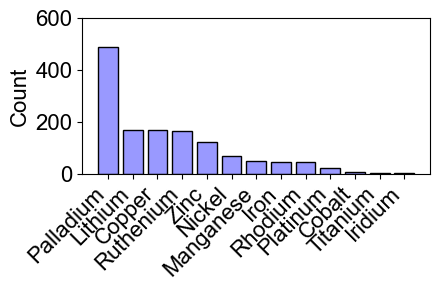

In [21]:
# Plot catalyst usage
plot = Plot(
    n_rows=1, n_cols=1, figsize=(4.5, 3),
    title_fontdict=title_fontdict,
    label_fontdict={'fontsize': 16},
    tick_fontdict={'fontsize': 16, 'fontweight': 'bold'},
    legend_fontdict=legend_fontdict
)

plot.add_bar(
    0, 0,
    categories=list(catalyst_counts.keys()),
    values=list(catalyst_counts.values()),
    rotation=45,
    colour="blue", 
    alpha=0.4,
    bar_edgecolor=["black"], 
    bar_edgewidth=[1.0],
    title="",
    x_label="",
    y_label="Count", 
    ymax=600
)

# Save reactions with catalysts to JSON file
os.makedirs(filepath, exist_ok=True)
with open(os.path.join(filepath, "catalyst_reactions_OPRD-100.json"), 'w') as f:
    json.dump(reactions_with_catalysts, f, indent=4)

plot.plot(savefig=True, filepath=filepath + "catalyst_usage_OPRD-100.png")